### drifting the integrable Harper model, not chaotic

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from scipy.integrate import odeint
import mpmath as mpmath
from scipy.optimize import linear_sum_assignment

# %matplotlib notebook 
%matplotlib inline 

import Husimi   # Quantum routines
import Harp     # Classical integration routines
import importlib  # for reloading routines if you need to edit them

In [ ]:
# consider using higher precision with mpmath 
# https://mpmath.org/
# https://mpmath.org/doc/current/matrices.html

# less relevant I think:
# this! https://github.com/c-f-h/flamp
# https://pypi.org/project/gmpy2/

In [2]:
import mpmath  # it is already installed!

In [6]:
mpmath.libmp.BACKEND   # I installed gmpy so it would be faster!

'gmpy'

In [3]:
print(mpmath.mp)

Mpmath settings:
  mp.prec = 53                [default: 53]
  mp.dps = 15                 [default: 15]
  mp.trap_complex = False     [default: False]


In [19]:
mpmath.mp.dps=50  # more decimal places, precission set here
print(mpmath.mp)

Mpmath settings:
  mp.prec = 169               [default: 53]
  mp.dps = 50                 [default: 15]
  mp.trap_complex = False     [default: False]


In [ ]:
# to use it I have to write a special routine to fill h0 with all numbers that are specified by mpmath

In [31]:
# create a high precission version of h0
def h0_prec(n,a,b,eps):
    fac = mpmath.fdiv(mpmath.fmul(2,mpmath.pi),mpmath.mpf(int(n)))  # 2*pi/N
    h0 = mpmath.zeros(int(n)) # not complex 
    for j in range(int(n)):
        phij = mpmath.fmul(fac,mpmath.mpf(j))
        ke = mpmath.fsub(mpmath.fmul(mpmath.cos(phij),mpmath.cos(mpmath.mpf(b))),\
                         mpmath.fmul(mpmath.sin(phij),mpmath.sin(mpmath.mpf(b))))
        h0[j,j] = mpmath.fmul(mpmath.mpf(eps),ke)
    for j in range(int(n)):
        h0[j,(j+1)%int(n)] = mpmath.fdiv(mpmath.mpf(a),mpmath.mpf(2))
        h0[(j+1)%int(n),j] = mpmath.fdiv(mpmath.mpf(a),mpmath.mpf(2))
    return h0 *mpmath.mpf(-1) 

# get eigenvalues and sort them in order of energy 
# using precision routines!
def h0_prec_eigs(n,a,b,eps):
    h0 = h0_prec(n,mpmath.mpf(a),mpmath.mpf(b),mpmath.mpf(eps)) 
    (w,vr) = mpmath.eigsy(h0) # returns real eigenvalues 
    #iphi = np.argsort(w.tolist())  # sort needs a list or array to work, this keeps mpf numbers in array
    iphi = np.argsort(np.array(w))  # sort in order of energy
    w_arr = np.array(w)
    w_sort = w_arr[iphi]  # sorted energies, is a sorted array of mpfs 
    vr_arr = np.array(vr)  # is 1d
    vr_arr = np.reshape(vr_arr, (n,n)) # is 2d now
    vrsort = vr_arr[:,iphi] # sorted eigenvectors now 2d array of mpfs
    return w_sort,vrsort

#n=3 # tests 
#h0 = h0_prec(n,mpmath.mpf(1),mpmath.mpf(0),mpmath.mpf(0.1)) 
#(w,vr) = mpmath.eigsy(h0)  #let's see if this works
#iphi = np.argsort(np.array(w))
#w_arr = np.array(w)
#w_sort = w_arr[iphi]

(w,vr)= h0_prec_eigs(3,1.,mpmath.mpf(0),mpmath.mpf(0.1)) 

In [14]:
importlib.reload(Husimi)  # if you need to reload it!

<module 'Husimi' from '/Users/aquillen/Desktop/summer24/pylab/QDrift/Husimi.py'>

In [3]:
importlib.reload(Harp)  # if you need to reload it!

<module 'Harp' from '/Users/aquillen/Desktop/summer24/pylab/QDrift/Harp.py'>

In [49]:
# for each eigenvalue in a list compute the distance to the nearest other one
# this routine uses mpmath
def min_de_vec(w_vec):
    n = len(w_vec)
    de_single_arr = np.zeros(n)
    for j in range(n):  # loop over eigenvalues 
        w = np.copy(w_vec)
        w[j] = mpmath.mpf(1e10)  # set its own eigenvalue to something ridiculously large so it won't contribute
        min_de = np.min(np.abs(w - w_vec[j]))  # not sure how to do this with mpmath 
        de_single_arr[j] = min_de
        #print(min_de)
    return de_single_arr

In [55]:
# sweep over n, return energies and de to nearest eigenvalues
# high precision version 
def n_de_sweep(eps,btype,nmin,nmax):
    wlist = []
    nlist = []
    delist = []

    a=mpmath.mpf(1.0)
    for k in range(nmin,nmax):
        n = k;  
        if (btype == 0):
            b = mpmath.mpf(0)
        else:
            b = mpmath.fdiv(mpmath.pi, mpmath.mpf(int(n)))
        n_arr = np.ones(n)*n # a list with n's in it
        nlist = np.append(nlist,n_arr)
        #(w,vr) = Husimi.h0_eigs(n,a,b,eps) # return eigenvalues, sorted in order of energy
        (w,vr) = h0_prec_eigs(n,a,b,eps) # try the precision version!
        wlist = np.append(wlist,w)  # was w-1
        de_vec = min_de_vec(w)
        delist = np.append(delist,de_vec)
    return nlist,wlist,delist
        


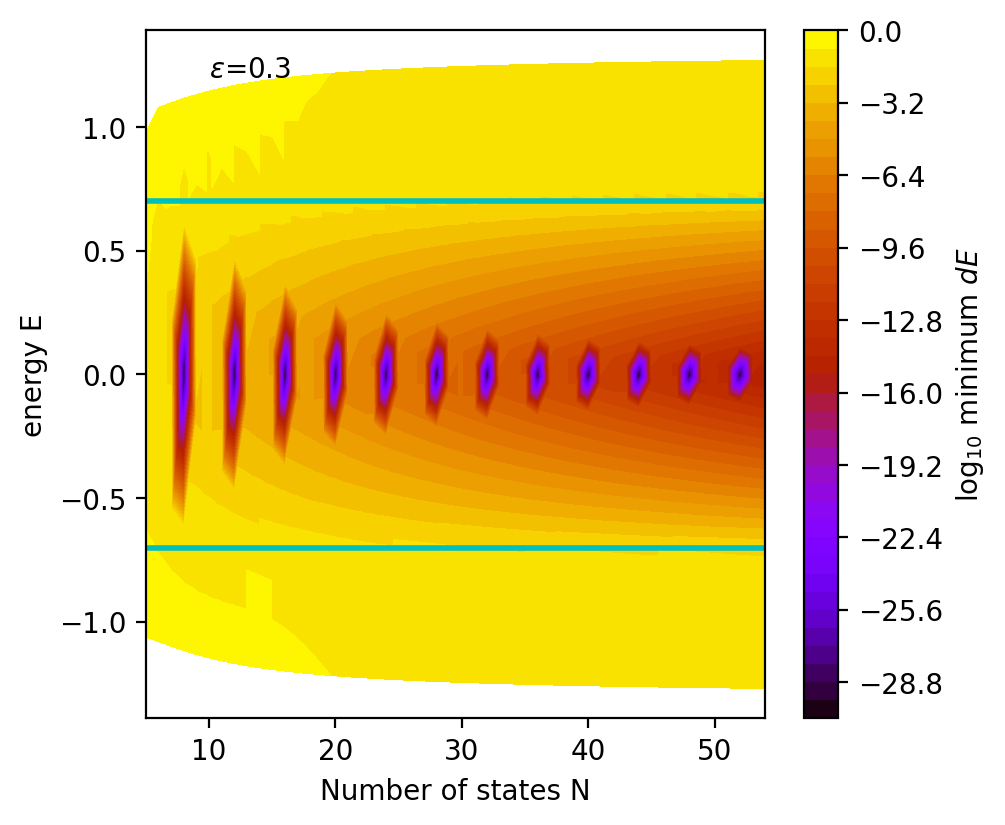

In [57]:
# makes a figure, given list of eigenvalues and nearest energy spacings 
def mkcontour_sweep(eps,nmin,nmax,nlist,wlist,delist,minimum_number,ofile):
    fig,ax = plt.subplots(1,1,figsize=(4.5,4),dpi=200)
    plt.subplots_adjust(left=0.12,top=0.98,right=0.98,bottom=0.12)
    #minimum_number = 1e-30
    delist_log = np.log10(delist+minimum_number)
    #ax.tricontour(nlist, wlist, delist_log, levels=14, linewidths=0.5, colors='k')
    cntr2 = ax.tricontourf(nlist, wlist, delist_log,  levels=40, cmap="gnuplot")
    cbar = fig.colorbar(cntr2, ax=ax)
    cbar.set_label(r'log$_{10}$ minimum $dE$')
    ax.set_xlabel('Number of states N')
    ax.set_ylabel('energy E')
    narr = np.arange(nmin,nmax)
    oarr = narr*0 + 1.0
    top = (1 - eps)*oarr
    bottom = -1*top*oarr
    ax.plot(narr,top,'c-',lw=2)
    ax.plot(narr,bottom,'c-',lw=2)
    ymax = 1+1.3*eps
    ax.set_ylim([-ymax,ymax])
    estr = r'$\epsilon$={:.1f}'.format(eps)
    ax.text(10,0.9+eps,estr)
    if (len(ofile)>3):
        plt.savefig(ofile+'.png')
    plt.show()

eps = 0.3;
nmin = 5
nmax = 55
nlist,wlist,delist = n_de_sweep(eps,0,nmin,nmax)
mkcontour_sweep(eps,nmin,nmax,nlist,wlist,delist,1e-30,'eee3')

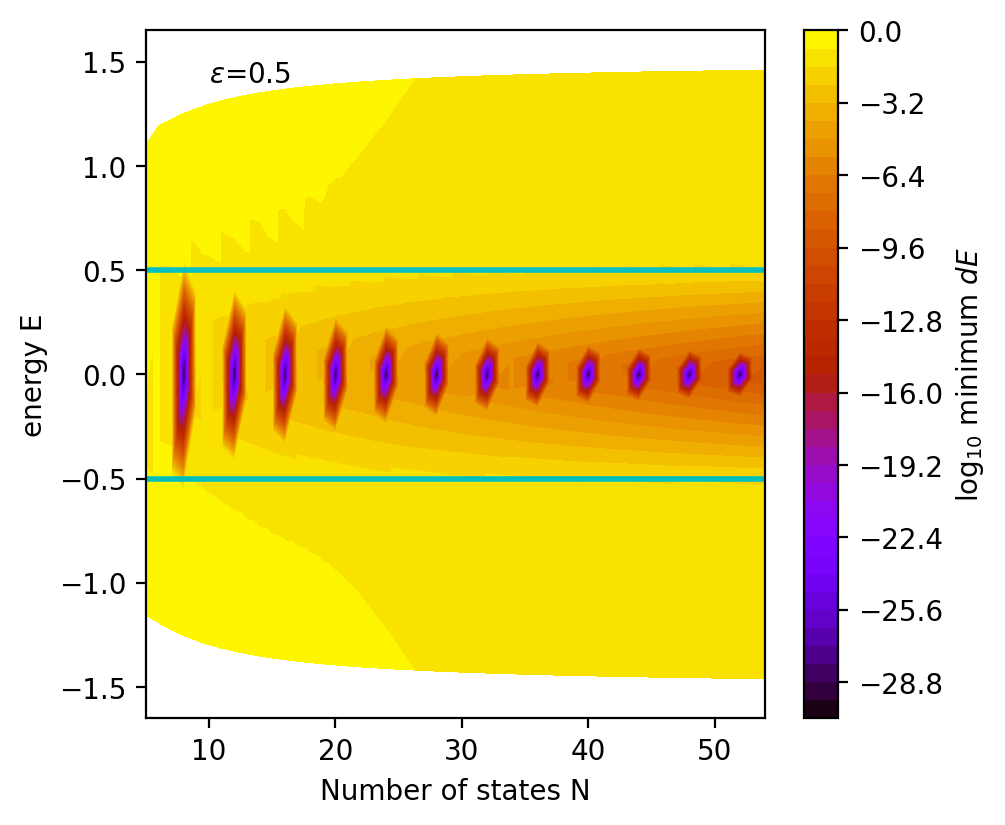

In [58]:
eps = 0.5;
nmin = 5
nmax = 55
nlist,wlist,delist = n_de_sweep(eps,0,nmin,nmax)
mkcontour_sweep(eps,nmin,nmax,nlist,wlist,delist,1e-30,'eee5')

In [69]:
# sweep over eps, return energies and de to nearest eigenvalues
def e_de_sweep(eps_min,eps_max,n_eps,btype,n):
    wlist = []
    eps_list = []
    delist = []
    eps_lin = np.linspace(eps_min,eps_max,n_eps)

    a=1.0
    if (btype == 0):
        b = 0.0
    else:
        b = np.pi/n
    for k in range(n_eps):
        eps = eps_lin[k]
        #(w,vr) = Husimi.h0_eigs(n,a,b,eps) # return eigenvalues, sorted in order of energy
        (w,vr) = h0_prec_eigs(n,a,b,eps) # try the precision version! sorted via energy
        wlist = np.append(wlist,w)  # was w-1
        #wlist = np.append(wlist,w-1)  #-1 here if using previous function h0_eigs
        eps_arr = np.zeros(n) + eps 
        eps_list = np.append(eps_list,eps_arr)  
        de_vec = min_de_vec(w)
        delist = np.append(delist,de_vec)
    return eps_list,wlist,delist
        

# make a figure showing a contour sweep made with above routine e_de_sweep()
# here n is number of states
# eps_list is list of epsilon values, 
# wlist, de list are energies and spacings at these epsilons
# low_lim is lower limit of de for taking log_10
def mkcontour_sweep_e(n,eps_list,wlist,delist,low_lim,ofile):
    fig,ax = plt.subplots(1,1,figsize=(4.5,4),dpi=200)
    delist_log = np.log10(delist+low_lim)
    #ax.tricontour(eps_list, wlist, delist_log, levels=14, linewidths=0.5, colors='k')
    cntr2 = ax.tricontourf(eps_list, wlist, delist_log,  levels=40, cmap="gnuplot")
    cbar = fig.colorbar(cntr2, ax=ax)
    cbar.set_label(r'log$_{10}$ minimum $dE$')
    ax.set_xlabel(r'$\epsilon$')
    ax.set_ylabel('energy E')
    eps_lin = np.linspace(np.min(eps_list),np.max(eps_list),20)
    top = (1 - eps_lin)
    bottom = -1*top
    ax.plot(eps_lin,top,'c-',lw=2)
    ax.plot(eps_lin,bottom,'c-',lw=2)
    ymax = 1+1.3*np.max(eps_list)
    ax.set_ylim([-ymax,ymax])
    estr = r'$N$={:.0f}'.format(n)
    ax.text(0.15,0.9+eps,estr)
    if (len(ofile)>3):
        plt.savefig(ofile+'.png')
    plt.show()




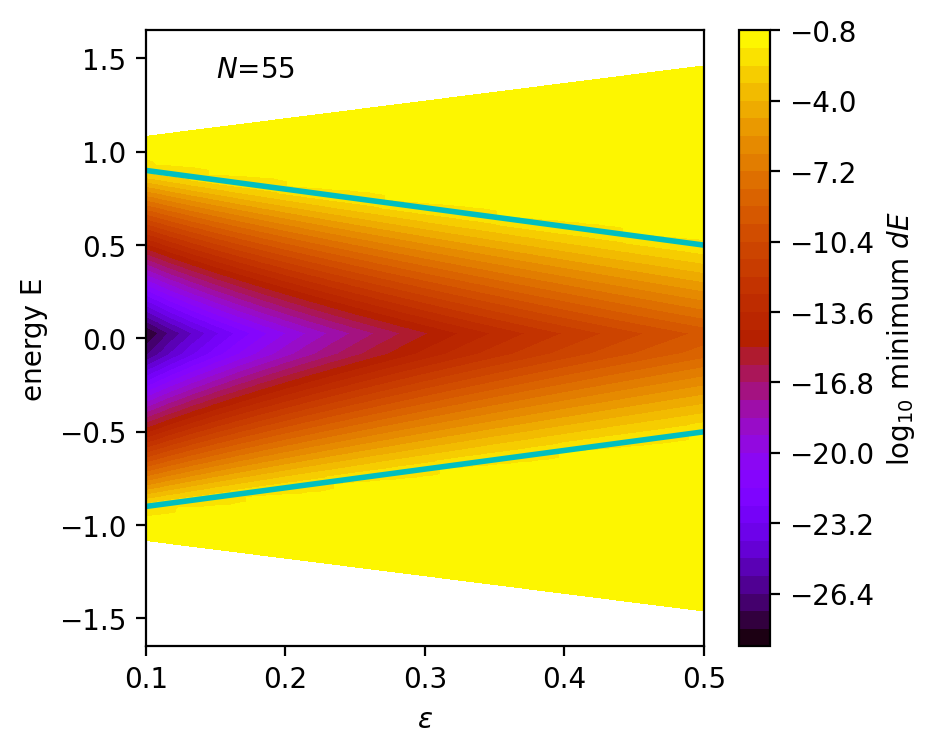

In [70]:
eps_min = 0.1
eps_max = 0.5
n_eps = 25
n=55
eps_list,wlist,delist = e_de_sweep(eps_min,eps_max,n_eps,0,n)
mkcontour_sweep_e(n,eps_list,wlist,delist,1e-30,'fff55')

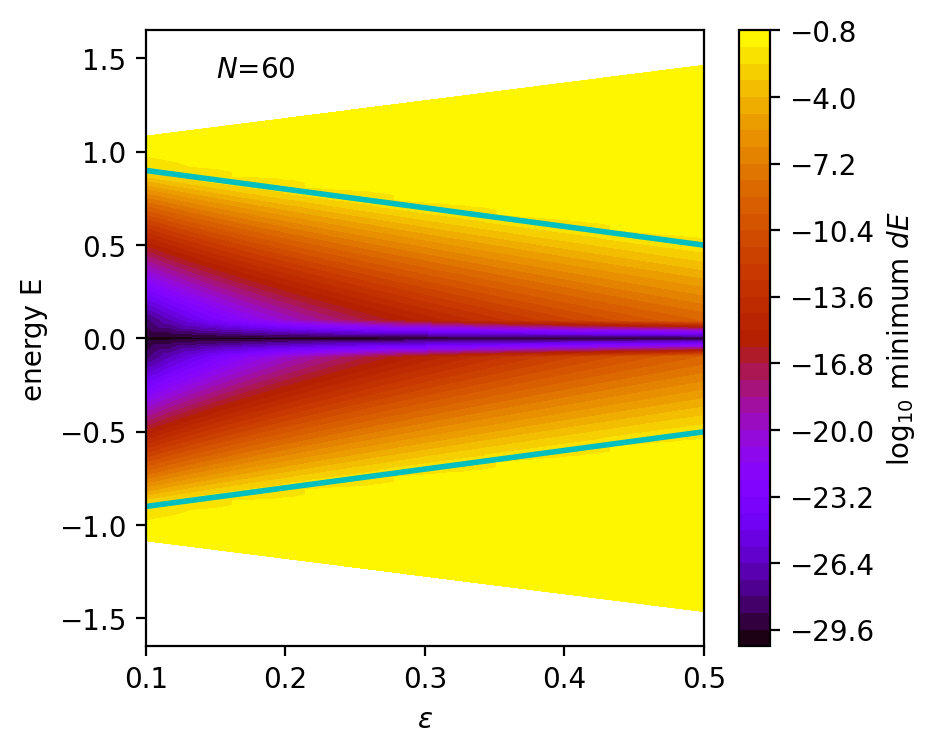

In [66]:
eps_min = 0.1
eps_max = 0.5
n_eps = 25
n=60
eps_list,wlist,delist = e_de_sweep(eps_min,eps_max,n_eps,0,n)
mkcontour_sweep_e(n,eps_list,wlist,delist,1e-30,'fff60')


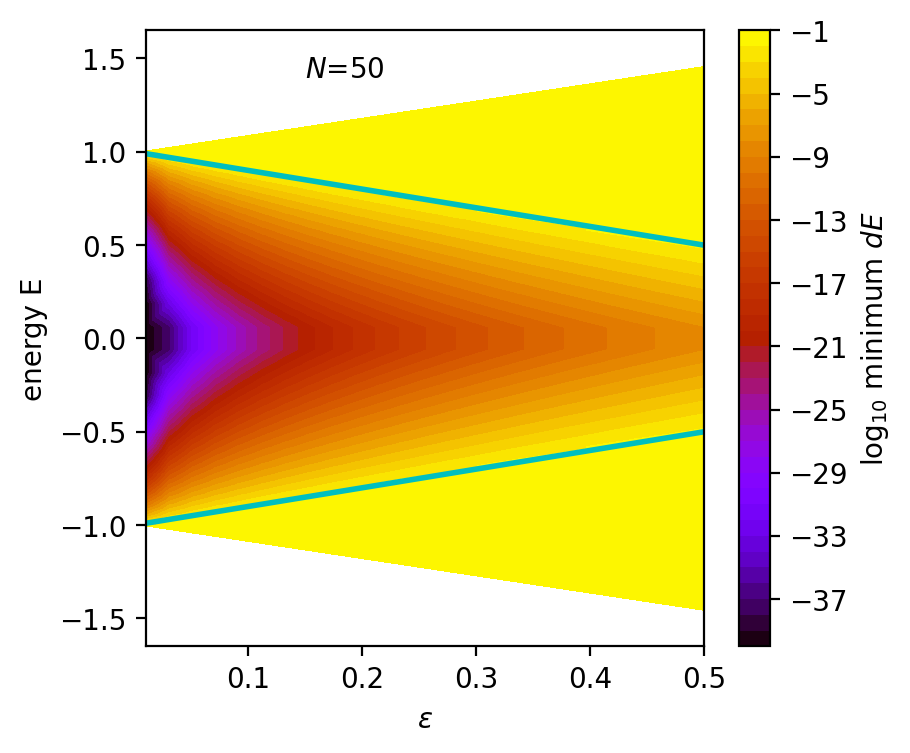

In [71]:
eps_min = 0.01
eps_max = 0.5
n_eps = 25
n=50
eps_list,wlist,delist = e_de_sweep(eps_min,eps_max,n_eps,0,n)
mkcontour_sweep_e(n,eps_list,wlist,delist,1e-40,'fff50')

In [77]:
# drift h0 slowly, nseries outputs
# drift rate per output is in dparms
# return sorted eigenvalues and eigenvectors, sorted in order of eigenvalue 
# uses Husimi.hat_h_0 routine for computing h0
def h0_drift(n,parms0,dparms,nseries):
    w_list = np.zeros((nseries,n),dtype=float)
    vr_list = np.zeros((nseries,n,n),dtype=complex)
    for k in range(nseries):
        parms = parms0 + dparms*k  # notice drift rate 
        a = parms[0] # note the order of the parameter list, these are current parameters
        b = parms[1]
        eps = parms[2]
        #mu =  parms[3]
        #mup =  parms[4]
        h0 = Husimi.hat_h_0_with_b(n,a,b,eps)  # the hamiltonian operator h_0
        (w,vr)=np.linalg.eigh(h0)   # find eigenvalues and eigenvectors 
        iphi = np.argsort(np.real(w))   # sort in order of energy 
        vrsort = vr[:,iphi] 
        w_list[k,:] = np.real(w[iphi]) # h_0 is Hermitian so they should be real. 
        vr_list[k,:,:] = vrsort  # sorted eigenvectors 
    print('a_final={:.6f}, b_final={:.6f}, eps_final={:.6f}'.format(a,b,eps))  # print the parameter values at the end 
    return w_list,vr_list 

# a class structure to hold drifting unperturbed system
# calls above routine h0_drift
class h0_drift_class():
    def __init__(self,n,parms0,dparms,nseries):
        self.n = n
        self.nseries = nseries
        self.parms0 = parms0
        self.dparms = dparms
        self.a_0   = parms0[0] # note the order of the parameter list, these are current parameters
        self.b_0   = parms0[1]
        self.eps_0 = parms0[2]
        self.d_a   = dparms[0]
        self.d_b   = dparms[1]
        self.d_eps = dparms[2]
        self.a_final   = self.a_0 + self.nseries*self.d_a
        self.b_final   = self.b_0 + self.nseries*self.d_b
        self.eps_final = self.eps_0 + self.nseries*self.d_eps

        # some vectors that display ranges 
        self.iis = np.arange(self.nseries)
        self.a_range = self.a_0 + self.d_a*self.iis 
        self.b_range = self.b_0 + self.d_b*self.iis 
        self.eps_range = self.eps_0 + self.d_eps*self.iis 
        
        # compute series of eigenvalues and eigenvectors 
        self.w_list,self.vr_list  = h0_drift(self.n,self.parms0,self.dparms,self.nseries)    
        # w_list: eigenvals [nseries,n] order h0
        # vr_list: eigenvecs [nseries,:,n] order h0
        #self.p_vec_list = parity_series(self.vr_list)  # compute parities for all these eigenvectors 
        # you can turn this off if not used, what came out did not make sense 
        
        #self.p_vec_list = parity_b_series(self.vr_list,self.b_range)
        # compute parities for all these eigenvectors 
        #self.de_list,self.arg_list = min_de_list(self.w_list)
        self.de_singles = min_de_singles(self.w_list)


# returns the closest distance to next nearest energy for each eigenvalue at each time in the series
def min_de_singles(w_list):
    nseries = w_list.shape[0]
    n = w_list.shape[1]
    de_singles_list = np.zeros([nseries,n])
    for k in range(nseries):  # each in the series 
        w_vec = np.squeeze(w_list[k,:])  # list of eigenvalues 
        for j in range(n):
            w = np.copy(w_vec)
            w[j] = 1e10   # set itself to something ridiculously large
            min_de = np.min(np.abs(w - w_vec[j]))
            de_singles_list[k,j] = min_de  # each eigenvalue has a min distance to nearest 
    return de_singles_list 
        

In [125]:
# compute separatix energy as a function of time 
# consistent with h0 defined in Husimi.py
def sep_energy(h0class):
    #a_vec = h0class.parms0[0] + h0class.dparms[0] * h0class.iis
    #eps_vec = h0class.parms0[2] + h0class.dparms[2] * h0class.iis
    top = 2*h0class.a_range - h0class.eps_range
    bottom = h0class.eps_range 
    return bottom,top  # separatrix energies as a function of time

from matplotlib import colors

# make a figure showing eigenvalues for a drifting series 
# energy is shifted by a but not flipped 
# color shows distance to nearest eigenvalue
def show_eigs(h0class,i0,i1,ymin,ymax,ofile):
    #i0=0;i1=nseries typically for entire range
    fig,ax = plt.subplots(1,1,figsize=(5,4),dpi=300)
    n  = h0class.n 
    
    if (h0class.d_b ==0):
        xx = h0class.eps_range[i0:i1]
        ax.set_xlabel(r'$\epsilon$')
    else:
        xx = h0class.b_range[i0:i1]
        ax.set_xlabel(r'resonance center $b$')

    if (h0class.d_b !=0) and (h0class.d_eps !=0):
        ax2 = ax.twiny()
        ax2.set_xlim([np.min(h0class.eps_range[i0:i1]),np.max(h0class.eps_range[i0:i1])])
        ax2.set_xlabel(r'resonance strength $\epsilon$')
        
    bottom,top = sep_energy(h0class)
    ax.plot(xx, bottom[i0:i1] - h0class.a_0,'r:',alpha=0.3,label='separatrix') # separatrix vals
    ax.plot(xx, top[i0:i1] - h0class.a_0 ,'r:',alpha=0.3)
    # notice shift in energy!
        
    colormap = plt.cm.viridis #or any other colormap
    normalize = colors.Normalize(vmin=-8, vmax=-0.3)

    for k in range(n):
        yy = np.squeeze(h0class.w_list[i0:i1,k]) - h0class.a_0   # notice shift in energy here!!!!!
        de = np.squeeze(np.log10(h0class.de_singles[i0:i1,k] + 1e-9))
        #ax.plot(xx, yy, 'k-',lw=0.5,alpha=0.5) 
        ss = ax.scatter(xx, yy, c=de, s=0.2, cmap=colormap, norm=normalize, marker='.')

    ax.set_ylim([ymin,ymax])
    ax.set_ylabel('Eigenvalues')
    #plt.colorbar(ss)

    cbar = fig.colorbar(ss, ax=ax)
    cbar.set_label(r'log$_{10}$ minimum $dE$')

    ax.text(0.2,0,'circulating')
    ax.text(1.5,1,'librating')
    ax.text(1.5,-1,'librating')
    ax.legend()

    if (len(ofile)>2):
        outfile = ofile + '_h0drift.png'
        plt.savefig(outfile)
        print(outfile)

    plt.show()


In [122]:
n=49; a=1.0; eps=0.0001; b=0.0; parms0 = np.array([a,b,eps])
nseries=300
d_a = 0.0; d_b = (2*np.pi/n)/20 ; d_eps = 0.5/nseries; 
dparms = np.array([d_a,d_b,d_eps])
xx1   = h0_drift_class(n,parms0,dparms,nseries)

a_final=1.000000, b_final=1.917013, eps_final=0.498433


xx1_h0drift.png


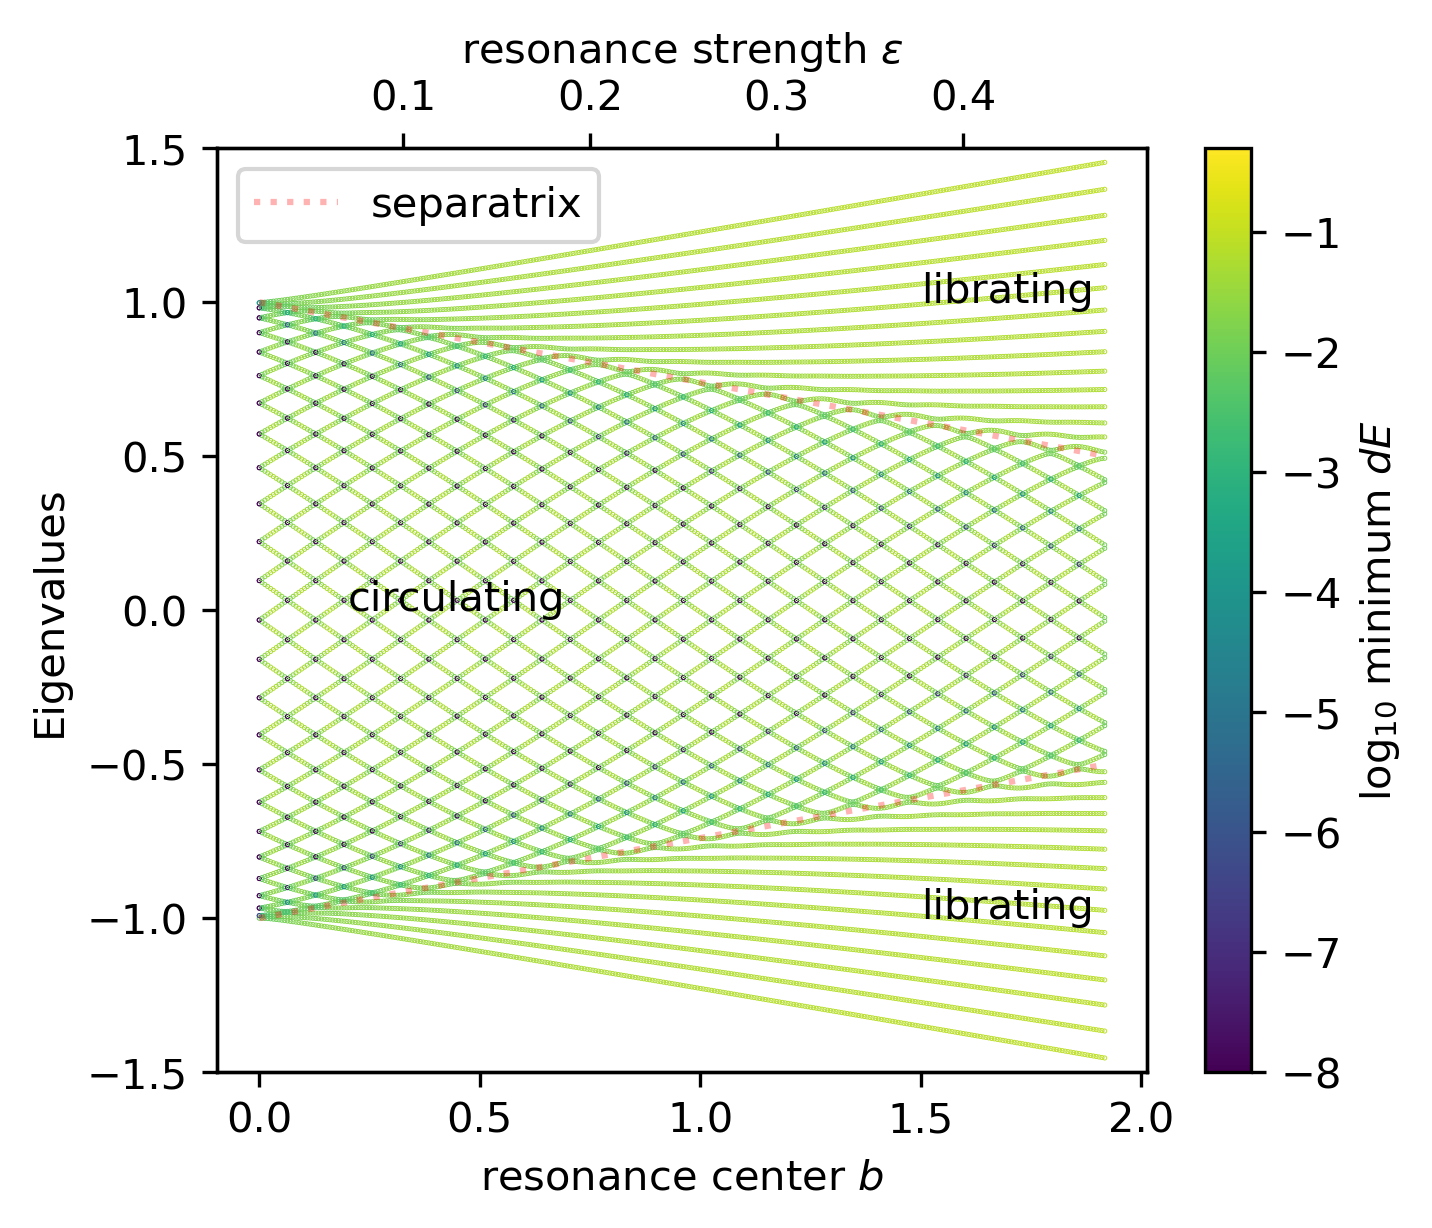

In [126]:
ymin = -1.5; ymax = 1.5
show_eigs(xx1,0,nseries,ymin,ymax,'xx1')